u L_max: 5.00e-01
u L_2: 3.71e+01


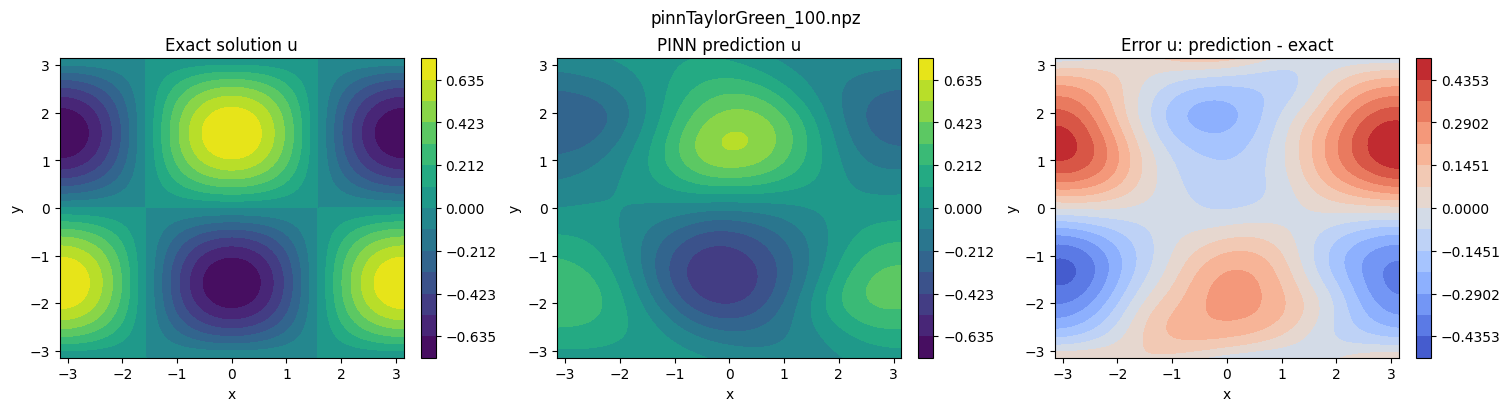

v L_max: 5.08e-01
v L_2: 4.28e+01


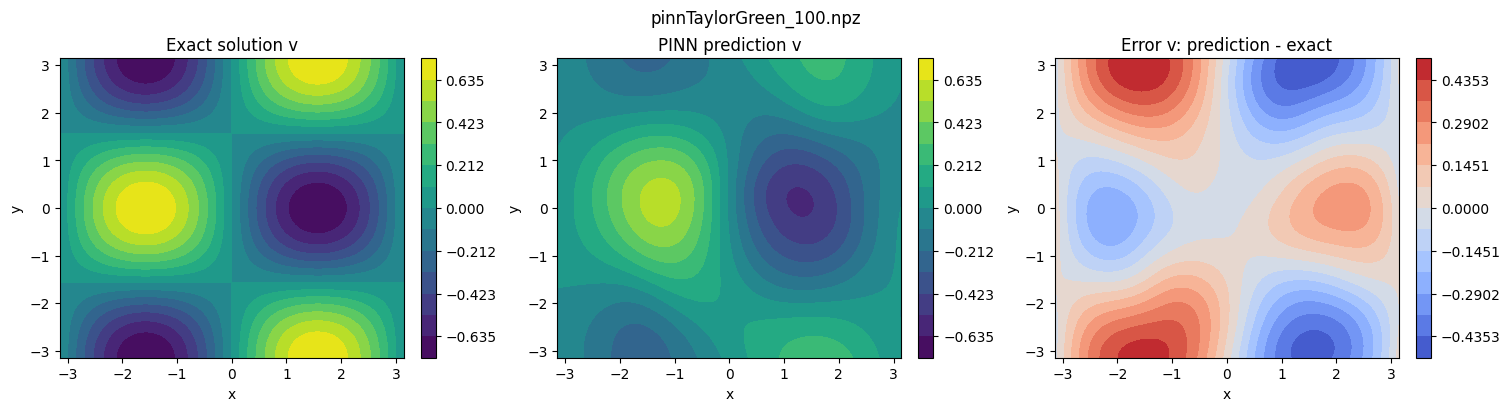

p L_max: 4.77e-01
p L_2: 5.66e+01


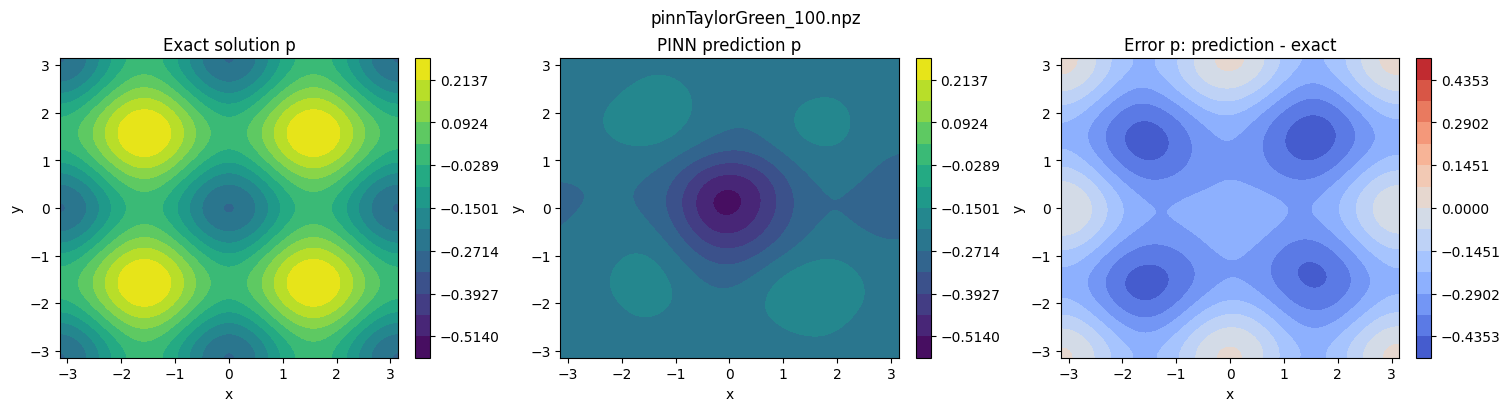

u L_max: 3.86e-01
u L_2: 3.23e+01


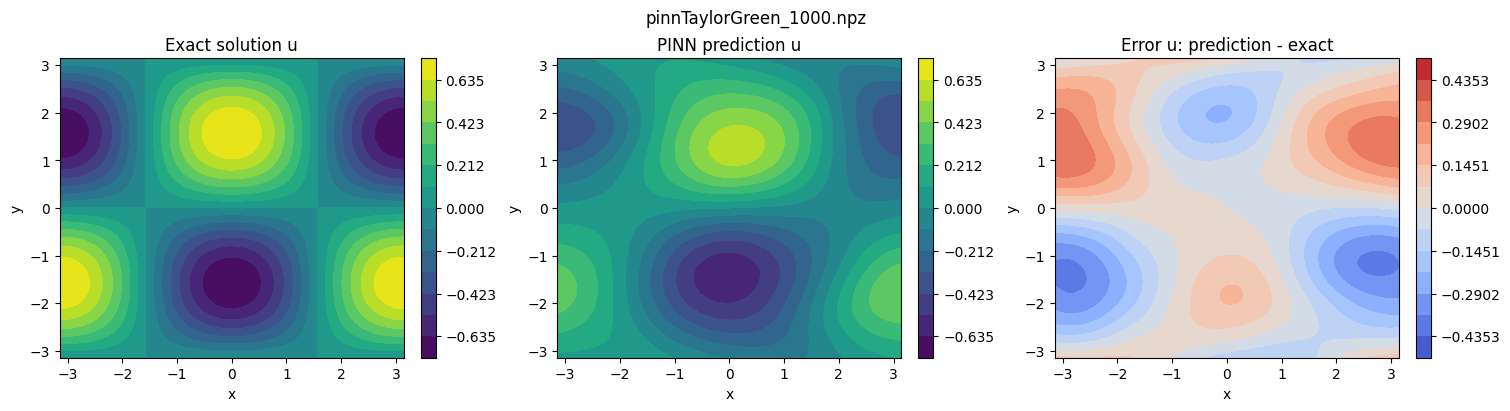

v L_max: 4.12e-01
v L_2: 3.26e+01


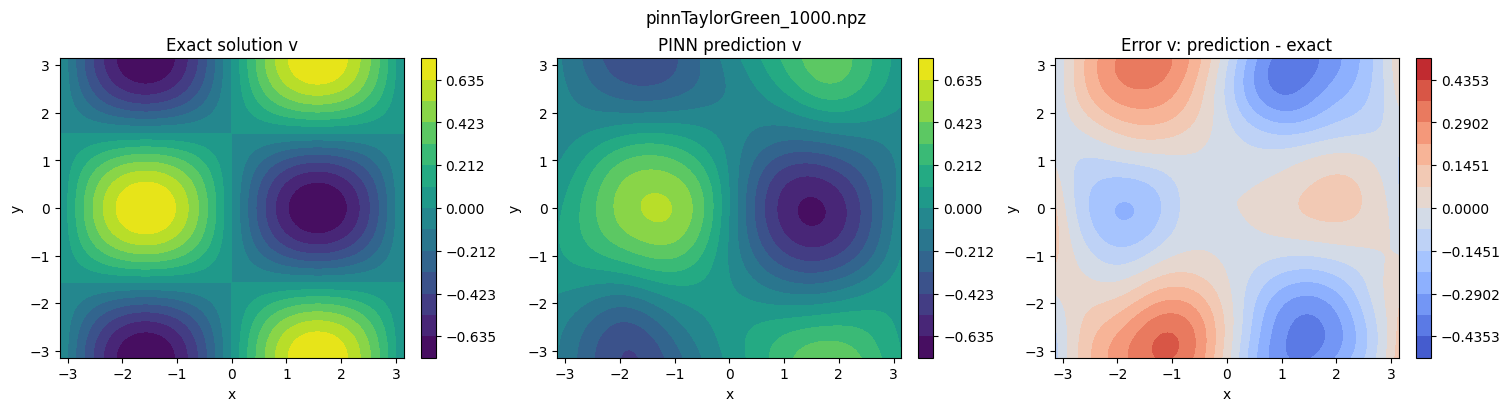

p L_max: 4.30e-01
p L_2: 5.38e+01


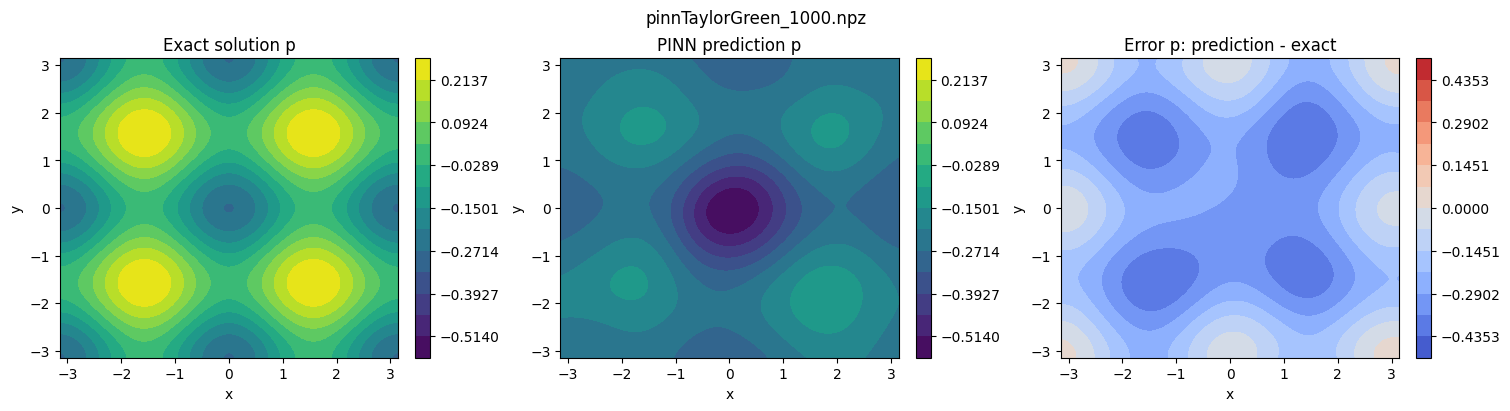

u L_max: 3.91e-01
u L_2: 3.19e+01


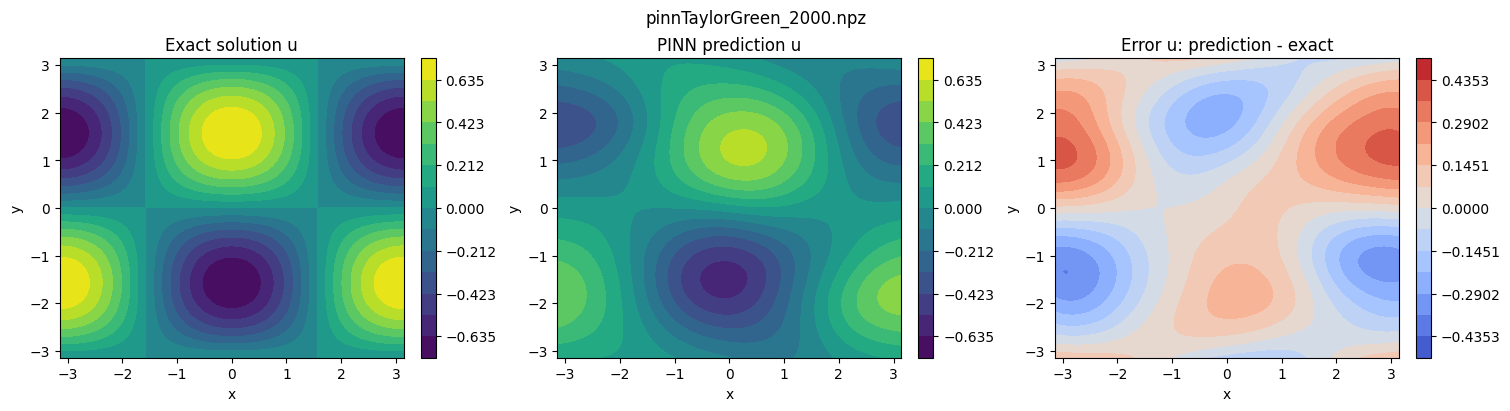

v L_max: 3.93e-01
v L_2: 3.14e+01


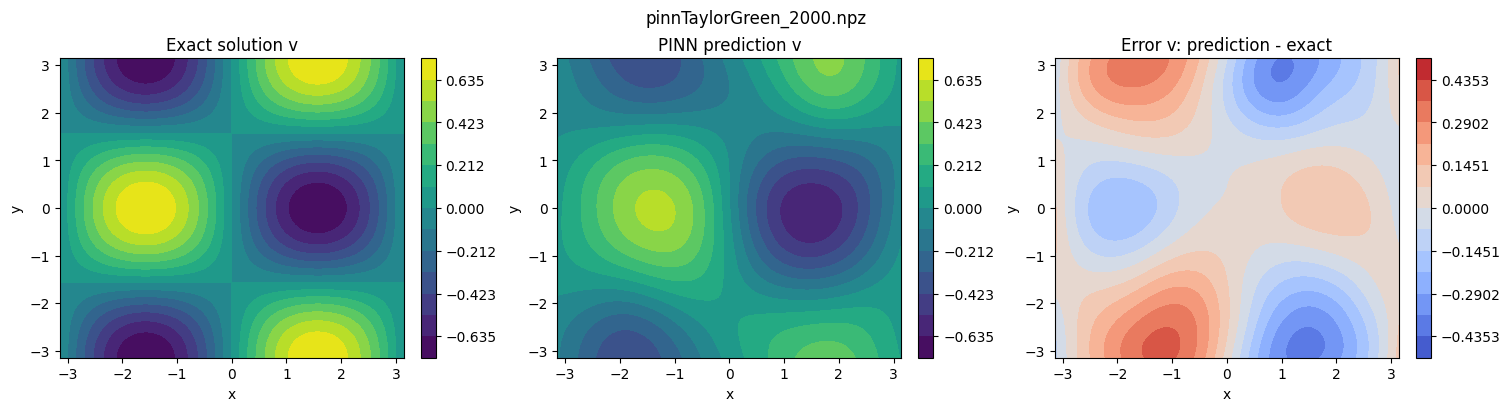

p L_max: 3.70e-01
p L_2: 4.27e+01


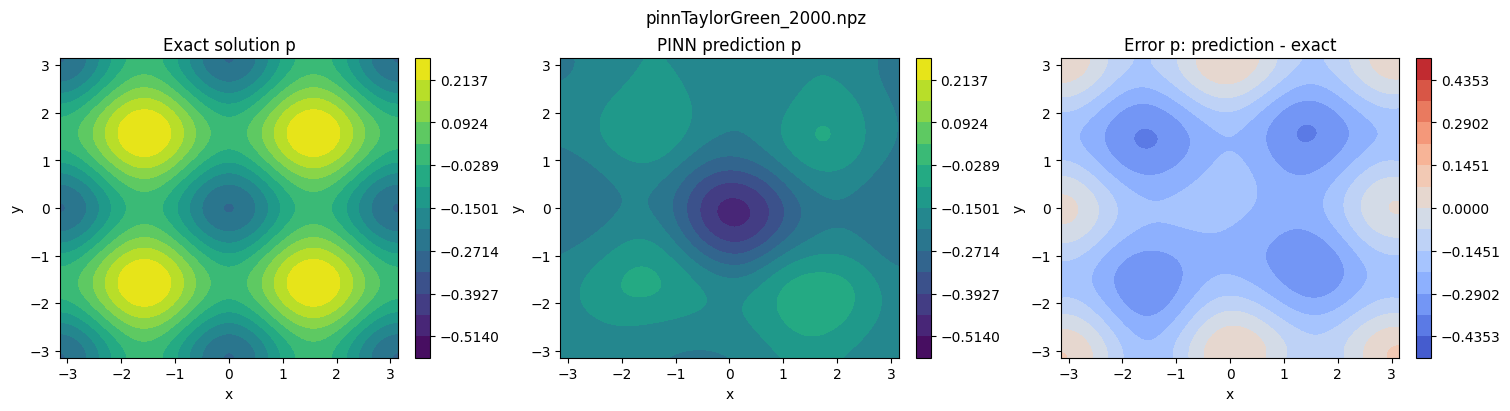

In [ ]:
#%%

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

files = [
    "pinnTaylorGreen_100.npz",
    "pinnTaylorGreen_1000.npz",
    "pinnTaylorGreen_2000.npz",
]

N_LEVELS = 15

#%%

#%%

u_min, u_max = np.inf, -np.inf
v_min, v_max = np.inf, -np.inf
p_min, p_max = np.inf, -np.inf
e_max = 0.0

for file in files:
    data = np.load(file)

    u_pred_n = data["u_pred_n"]
    v_pred_n = data["v_pred_n"]
    p_pred_n = data["p_pred_n"]

    u_exact_n = data["u_exact_n"]
    v_exact_n = data["v_exact_n"]
    p_exact_n = data["p_exact_n"]

    u_min = min(u_min, u_pred_n.min(), u_exact_n.min())
    u_max = max(u_max, u_pred_n.max(), u_exact_n.max())

    v_min = min(v_min, v_pred_n.min(), v_exact_n.min())
    v_max = max(v_max, v_pred_n.max(), v_exact_n.max())

    p_min = min(p_min, p_pred_n.min(), p_exact_n.min())
    p_max = max(p_max, p_pred_n.max(), p_exact_n.max())

    u_e_max = np.max(np.abs(u_pred_n - u_exact_n))
    v_e_max = np.max(np.abs(v_pred_n - v_exact_n))
    p_e_max = np.max(np.abs(p_pred_n - p_exact_n))

    e_max = max(e_max, u_e_max, v_e_max, p_e_max)

levels1 = np.linspace(u_min, u_max, N_LEVELS)
levels2 = np.linspace(v_min, v_max, N_LEVELS)
levels3 = np.linspace(p_min, p_max, N_LEVELS)
e_levels = np.linspace(-e_max, e_max, N_LEVELS)

e_norm = TwoSlopeNorm(
    vmin=-e_max,
    vcenter=0.0,
    vmax=e_max
)

#%%

def plot_npz_file(file):
    data = np.load(file)

    Xn = data["Xn"]
    Yn = data["Yn"]

    u_pred_n = data["u_pred_n"]
    v_pred_n = data["v_pred_n"]
    p_pred_n = data["p_pred_n"]

    u_exact_n = data["u_exact_n"]
    v_exact_n = data["v_exact_n"]
    p_exact_n = data["p_exact_n"]

    fields = [
        ("u", u_exact_n, u_pred_n, levels1),
        ("v", v_exact_n, v_pred_n, levels2),
        ("p", p_exact_n, p_pred_n, levels3),
    ]

    for name, exact, pred, levels in fields:
        fig, axes = plt.subplots(
            1, 3,
            figsize=(15, 4),
            constrained_layout=True
        )

        fig.suptitle(f"{file}")

        # Exact
        cf1 = axes[0].contourf(Xn, Yn, exact, levels=levels)
        axes[0].set_title(f"Exact solution {name}")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")
        fig.colorbar(cf1, ax=axes[0])

        # Prediction
        cf2 = axes[1].contourf(Xn, Yn, pred, levels=levels)
        axes[1].set_title(f"PINN prediction {name}")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        fig.colorbar(cf2, ax=axes[1])

        # Error
        error = pred - exact

        cf3 = axes[2].contourf(
            Xn, Yn,
            error,
            levels=e_levels,
            norm=e_norm,
            cmap="coolwarm"
        )
        axes[2].set_title(f"Error {name}: prediction - exact")
        axes[2].set_xlabel("x")
        axes[2].set_ylabel("y")
        fig.colorbar(cf3, ax=axes[2])

        plt.show()

        L_max = np.max(np.abs(error))
        L_2 = np.linalg.norm(error)
        print(f'{name} L_max: {L_max:.2e}')
        print(f'{name} L_2: {L_2:.2e}')
#%%

for file in files:
    plot_npz_file(file)